In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

z=wx+b --st. line   
..............................................         
sigmoid func [g(z)] = 1/(1+$e^{-z}$)    
..............................................   
cost func = (1/m)∑L(y',$y_{i}$)  
where, L(y',$y_{i}$) = -yi log(g($z_{i}$)) -(1-yi) log(1- g($z_{i}$))  
..............................................  
gradient decent  
w= w - α * dc_dw  
b= b - α * dc_db  
where  
dc_dw= (1/m)∑($g_{i}$-$y_{i}$)* $x_{i,j}$  
dc_db= (1/m)∑($g_{i}$-$y_{i}$)

In [40]:
data=pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\Machine Learning\0.Data\LogR.csv')
data.head()

,Study_Hours,Attendance,Result
0,1,55,0
1,2,60,0
2,3,65,0
3,4,70,0
4,5,75,1


In [41]:
x_train=data[['Study_Hours','Attendance']].values
y_train=data['Result'].values
m,n=x_train.shape

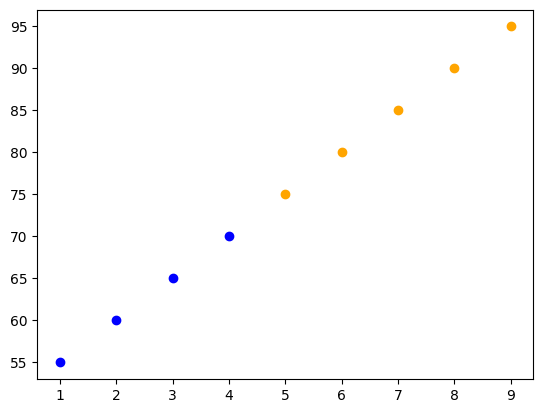

In [42]:
plt.scatter(x_train[y_train == 0,0],x_train[y_train == 0,1],color='blue')
plt.scatter(x_train[y_train == 1,0],x_train[y_train == 1,1],color='orange')
plt.show()

In [43]:
def sigmoid_func(z):
    val=1/(1 + np.exp(-z))
    return val

In [44]:
def cost_func(x,y,w,b):
    cost_sum=0

    for i in range(m):
        z= np.dot(w,x[i]) + b
        g=sigmoid_func(z)
        L= -y[i]*np.log(g) - (1-y[i])*np.log(1-g)
        cost_sum+=L
        
    final_cost=(1/m)*cost_sum
    
    return final_cost

In [45]:
def gradient_func(x,y,w,b):
    grad_w= np.zeros(n)
    grad_b=0

    for i in range(m):
        z= np.dot(w,x[i]) + b
        g= sigmoid_func(z)
        
        grad_b+=(g-y[i])
        for j in range(n):
            grad_w[j]+=(g-y[i])*x[i,j]
    
    grad_w=(1/m)*grad_w
    grad_b=(1/m)*grad_b

    return grad_w,grad_b

In [49]:
def gradient_descent(x,y,alpha,iteration):
    w=np.zeros(n)
    b=0

    for i in range(iteration):
        dc_dw,dc_db=gradient_func(x,y,w,b)

        w=w - alpha*dc_dw
        b=b - alpha*dc_db

        if i%1000==0:
            print(f"iteration :{i} cost : {cost_func(x,y,w,b)}")

    return w,b

In [47]:
def predict(x,w,b):
    pred=np.zeros(len(x))

    for i in range(m):
        z=np.dot(w,x[i]) + b
        g=sigmoid_func(z)

        if g>=0.5 :
            pred[i]=1
        else:
            pred[i]=0
    
    return pred

In [50]:
learning_rate=0.01
iterations=10000
final_w,final_b=gradient_descent(x_train,y_train,learning_rate,iterations)
final_w,final_b

iteration :0 cost : 2.7176049132427327
iteration :1000 cost : 0.1602223719179291
iteration :2000 cost : 0.046100145390570446
iteration :3000 cost : 0.0436175718935861
iteration :4000 cost : 0.04141977144877141
iteration :5000 cost : 0.039455352984070456
iteration :6000 cost : 0.03768541980725566
iteration :7000 cost : 0.036079841800714836
iteration :8000 cost : 0.034614817171278206
iteration :9000 cost : 0.03327122461109131


(array([ 5.42523287, -0.32858543]), -0.5490949959845924)

In [53]:
predictions=predict(x_train,final_w,final_b)
accuracy=np.mean(predictions==y_train)
accuracy*100

100.0

In [55]:
from sklearn.metrics import r2_score

In [56]:
r2_score(y_train,predictions)*100

100.0

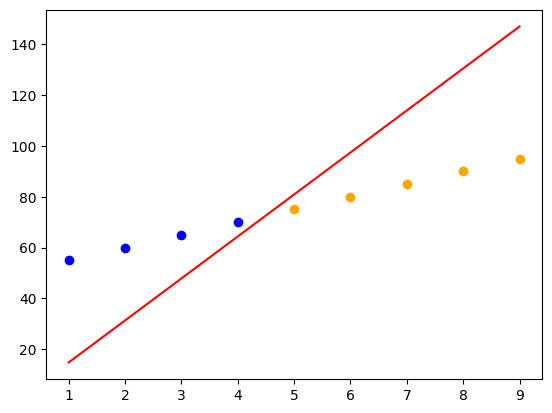

In [59]:
plt.scatter(x_train[y_train == 0,0],x_train[y_train == 0,1],color='blue')
plt.scatter(x_train[y_train == 1,0],x_train[y_train == 1,1],color='orange')
x_values = np.array([
    x_train[:,0].min(),
    x_train[:,0].max()
])

y_values = -(final_w[0]*x_values + final_b) / final_w[1]

plt.plot(x_values,y_values,color='red')
plt.show()

In [60]:
x_values

array([1, 9], dtype=int64)

In [61]:
y_values

array([ 14.8397873, 146.9267855])

In [64]:
final_w,final_b

(array([ 5.42523287, -0.32858543]), -0.5490949959845924)